# ver18. SAM Foreground + Occlusion Heatmap + BiomedCLIP Classifier + LLM

이 노트북은 ver17에서 한 단계 더 나아가, 모델이 스스로 중요하게 본 영역을 설명하기 위한 **occlusion sensitivity heatmap**을 추가합니다.

최종 역할 분담:

1. **SAM**: MRI의 brain foreground를 분리하고 배경을 줄이는 segmentation foundation model
2. **BiomedCLIP adapter classifier**: 정상/비정상 screening 확률을 계산하는 최종 분류기
3. **Occlusion sensitivity**: classifier의 예측 확신에 영향을 준 image patch를 시각화
4. **LLM**: SAM mask, classifier 확률, occlusion heatmap을 통합해 한국어 report 생성

중요한 표현:

- SAM mask는 병변 위치가 아니라 brain foreground mask입니다.
- Occlusion heatmap은 임상 병변 ROI가 아니라 **model-derived importance region**입니다.
- 전문의 annotation 없이 모델이 어느 구역에 민감했는지 보여주는 설명 도구입니다.


## 1. 환경 점검


In [1]:
import os
import sys
import re
import json
import random
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import requests

from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

# Hugging Face Hub의 비인증 다운로드 경고는 실행에는 영향이 없어서 노트북 출력에서는 숨깁니다.
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)

SEED = 42


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python executable : {sys.executable}")
print(f"Python version    : {sys.version}")
print(f"torch version     : {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("GPU name          : CUDA GPU not available")
print(f"device            : {device}")


Python executable : C:\Users\user\anaconda3\envs\alzheimer\python.exe
Python version    : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
torch version     : 2.12.0.dev20260408+cu128
torch.version.cuda: 12.8
cuda available    : True
GPU name          : NVIDIA GeForce RTX 5070
device            : cuda


## 2. 경로 및 실행 옵션


In [2]:
PROJECT_DIR = Path(r"C:\Users\user\alzheimer")
DATA_ROOT = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data")

FOUNDATION_DIR = PROJECT_DIR / "patient_level_stage1_foundation"
CACHE_PATH = FOUNDATION_DIR / "cache" / "non_vs_demented_biomedclip_all_original_features.pt"
MANIFEST_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_all_images_manifest.csv"
PATIENT_TABLE_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_patient_table.csv"
FOLD_RESULTS_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_fold_results.csv"
CHECKPOINT_DIR = FOUNDATION_DIR / "checkpoints"

OUTPUT_DIR = PROJECT_DIR / "sam_occlusion_llm_pipeline"
ASSET_DIR = OUTPUT_DIR / "demo_assets"
REPORT_DIR = OUTPUT_DIR / "llm_reports"
PROMPT_DIR = OUTPUT_DIR / "llm_prompts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
PROMPT_DIR.mkdir(parents=True, exist_ok=True)

# Foundation models
MODEL_NAME = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
SAM_MODEL_TYPE = "vit_b"
SAM_CHECKPOINT = Path(r"C:\Users\user\alzheimer\models\sam_vit_b_01ec64.pth")

# Occlusion sensitivity 설정
OCCLUSION_GRID_ROWS = 8
OCCLUSION_GRID_COLS = 8
OCCLUSION_BATCH_SIZE = 32
MIN_FOREGROUND_OVERLAP = 0.05
TOP_PATCHES_TO_DRAW = 6

# 실제 LLM 연결. LM Studio 화면에 표시된 주소와 모델명을 기본값으로 사용합니다.
# Ollama OpenAI-compatible를 쓰면 http://localhost:11434/v1 로 바꾸세요.
RUN_LLM = True
LLM_API_BASE = os.environ.get("LLM_API_BASE", "http://127.0.0.1:1234/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "not-needed")
LLM_MODEL = os.environ.get("LLM_MODEL", "google/gemma-4-e4b")
LLM_TIMEOUT_SECONDS = 120

required_paths = [
    DATA_ROOT,
    FOUNDATION_DIR,
    CACHE_PATH,
    MANIFEST_PATH,
    PATIENT_TABLE_PATH,
    FOLD_RESULTS_PATH,
    CHECKPOINT_DIR,
    SAM_CHECKPOINT,
]
for path in required_paths:
    assert Path(path).exists(), f"필수 경로가 없습니다: {path}"

print(f"DATA_ROOT      : {DATA_ROOT}")
print(f"FOUNDATION_DIR : {FOUNDATION_DIR}")
print(f"OUTPUT_DIR     : {OUTPUT_DIR}")
print(f"MODEL_NAME     : {MODEL_NAME}")
print(f"SAM checkpoint : {SAM_CHECKPOINT}")
print(f"LLM_API_BASE   : {LLM_API_BASE}")
print(f"RUN_LLM        : {RUN_LLM}")


DATA_ROOT      : C:\Users\user\Desktop\alzheimer_dataset\Data
FOUNDATION_DIR : C:\Users\user\alzheimer\patient_level_stage1_foundation
OUTPUT_DIR     : C:\Users\user\alzheimer\sam_occlusion_llm_pipeline
MODEL_NAME     : hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
SAM checkpoint : C:\Users\user\alzheimer\models\sam_vit_b_01ec64.pth
LLM_API_BASE   : http://127.0.0.1:1234/v1
RUN_LLM        : True


## 3. SAM과 BiomedCLIP 실제 로드


In [3]:
try:
    from segment_anything import SamPredictor, sam_model_registry
except Exception as exc:
    raise RuntimeError(
        "segment_anything 패키지가 필요합니다. "
        "`pip install segment-anything opencv-python requests`를 실행하세요."
    ) from exc

import open_clip

sam_model = sam_model_registry[SAM_MODEL_TYPE](checkpoint=str(SAM_CHECKPOINT))
sam_model = sam_model.to(device)
sam_model.eval()
sam_predictor = SamPredictor(sam_model)

print(f"SAM loaded: {SAM_MODEL_TYPE}")
print(f"SAM device: {next(sam_model.parameters()).device}")

print("\nBiomedCLIP 로드 중...")
biomed_model, preprocess = open_clip.create_model_from_pretrained(MODEL_NAME)
biomed_model = biomed_model.to(device)
biomed_model.eval()

print(f"BiomedCLIP device: {next(biomed_model.parameters()).device}")
assert next(sam_model.parameters()).device.type == device.type
assert next(biomed_model.parameters()).device.type == device.type


SAM loaded: vit_b
SAM device: cuda:0

BiomedCLIP 로드 중...
BiomedCLIP device: cuda:0


## 4. 기존 adapter classifier 결과 복원


In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
patient_table = pd.read_csv(PATIENT_TABLE_PATH)
fold_results = pd.read_csv(FOLD_RESULTS_PATH)
cached_features = torch.load(CACHE_PATH, map_location="cpu", weights_only=False)

adapter_fold_results = (
    fold_results[fold_results["experiment"] == "adapter_probe"]
    .sort_values("fold")
    .reset_index(drop=True)
)
assert len(adapter_fold_results) == 5, "adapter_probe 5-fold 결과가 필요합니다."

print(f"Images   : {len(manifest):,}")
print(f"Patients : {len(patient_table):,}")
print(f"Feature tensor shape: {tuple(cached_features['features'].shape)}")
display(adapter_fold_results)


Images   : 86,437
Patients : 347
Feature tensor shape: (86437, 512)


,experiment,fold,best_epoch,val_auroc,selected_threshold,validation_target_reached,test_patients,default_sensitivity,default_specificity,default_f1,calibrated_accuracy,calibrated_precision,calibrated_sensitivity,calibrated_specificity,calibrated_f1,calibrated_macro_f1,auroc,auprc,trainable_params,total_params
0,adapter_probe,1,9,0.896875,0.375,True,70,0.625000,0.870370,0.606061,0.842857,0.608696,0.8750,0.833333,0.717949,0.804519,0.907407,0.710235,133762,133762
1,adapter_probe,2,2,0.893750,0.400,True,70,0.941176,0.886792,0.820513,0.857143,0.629630,1.0000,0.811321,0.772727,0.834280,0.963374,0.837076,133762,133762
2,adapter_probe,3,8,0.896875,0.325,True,69,0.625000,0.886792,0.625000,0.826087,0.600000,0.7500,0.849057,0.666667,0.774510,0.867925,0.651108,133762,133762
3,adapter_probe,4,1,0.950000,0.425,True,69,0.500000,0.830189,0.484848,0.797101,0.541667,0.8125,0.792453,0.650000,0.753571,0.866745,0.656490,133762,133762
4,adapter_probe,5,1,0.953125,0.475,True,69,0.812500,0.830189,0.684211,0.869565,0.640000,1.0000,0.830189,0.780488,0.843852,0.899764,0.618640,133762,133762


In [5]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
patient_indices = np.arange(len(patient_table))
patient_targets = patient_table["target"].to_numpy()

fold_assignment = {}
for fold_number, (_, outer_test_idx) in enumerate(
    outer_cv.split(patient_indices, patient_targets),
    start=1,
):
    for patient_id in patient_table.iloc[outer_test_idx]["patient_id"]:
        fold_assignment[patient_id] = fold_number

patient_table = patient_table.copy()
patient_table["fold"] = patient_table["patient_id"].map(fold_assignment)
assert patient_table["fold"].notna().all()

display(
    patient_table.groupby(["fold", "target"])
    .size()
    .unstack(fill_value=0)
)


target,0,1
fold,,
1,54,16
2,53,17
3,53,16
4,53,16
5,53,16


In [6]:
ADAPTER_HIDDEN_DIM = 128
ADAPTER_DROPOUT = 0.2
PREDICT_BATCH_SIZE = 4096
feature_dim = int(cached_features["features"].shape[1])


class AdapterProbe(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.adapter = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )
        self.classifier = nn.Linear(input_dim, 2)

    def forward(self, features):
        normalized = self.norm(features)
        adapted = normalized + self.adapter(normalized)
        return self.classifier(adapted)


def load_adapter_checkpoint(fold_number: int):
    checkpoint_path = CHECKPOINT_DIR / f"adapter_probe_fold{fold_number}.pt"
    assert checkpoint_path.exists(), f"checkpoint 없음: {checkpoint_path}"
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    model = AdapterProbe(
        input_dim=int(checkpoint["feature_dim"]),
        hidden_dim=ADAPTER_HIDDEN_DIM,
        dropout=ADAPTER_DROPOUT,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model, checkpoint


def aggregate_patient_predictions(patient_ids, labels, probabilities):
    df = pd.DataFrame({
        "patient_id": patient_ids,
        "target": labels,
        "image_probability": probabilities,
    })
    return (
        df.groupby("patient_id", as_index=False)
        .agg(
            target=("target", "first"),
            probability=("image_probability", "mean"),
            image_probability_std=("image_probability", "std"),
            image_count=("image_probability", "count"),
        )
    )


def predict_patients_with_fold_checkpoint(fold_number: int, patient_ids):
    patient_id_set = set(patient_ids)
    indices = [
        index
        for index, patient_id in enumerate(cached_features["patient_ids"])
        if patient_id in patient_id_set
    ]
    assert indices, f"fold {fold_number}에 해당하는 이미지 index가 없습니다."

    model, checkpoint = load_adapter_checkpoint(fold_number)
    features = cached_features["features"][indices].float()
    labels = cached_features["labels"][indices].long().numpy()
    batch_patient_ids = [cached_features["patient_ids"][i] for i in indices]

    probabilities = []
    with torch.inference_mode():
        for start in range(0, len(indices), PREDICT_BATCH_SIZE):
            end = min(start + PREDICT_BATCH_SIZE, len(indices))
            batch_features = features[start:end].to(device, non_blocking=True)
            logits = model(batch_features)
            batch_probs = logits.softmax(dim=1)[:, 1]
            probabilities.extend(batch_probs.detach().cpu().numpy().tolist())

    patient_pred = aggregate_patient_predictions(
        batch_patient_ids,
        labels,
        probabilities,
    )
    patient_pred["fold"] = fold_number
    patient_pred["threshold"] = float(checkpoint["selected_threshold"])
    patient_pred["pred_label"] = (
        patient_pred["probability"] >= patient_pred["threshold"]
    ).astype(int)
    return patient_pred


def calculate_oof_metrics(oof_df):
    y_true = oof_df["target"].to_numpy()
    y_prob = oof_df["probability"].to_numpy()
    y_pred = oof_df["pred_label"].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "patients": len(oof_df),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
    }


oof_parts = []
for fold_number in range(1, 6):
    fold_patient_ids = patient_table.loc[
        patient_table["fold"] == fold_number,
        "patient_id",
    ].tolist()
    oof_parts.append(
        predict_patients_with_fold_checkpoint(fold_number, fold_patient_ids)
    )

oof_predictions = pd.concat(oof_parts, ignore_index=True)
oof_predictions = oof_predictions.merge(
    patient_table[["patient_id", "class_name"]],
    on="patient_id",
    how="left",
)
oof_predictions = oof_predictions[
    [
        "patient_id",
        "class_name",
        "target",
        "fold",
        "image_count",
        "probability",
        "image_probability_std",
        "threshold",
        "pred_label",
    ]
].sort_values(["fold", "patient_id"])

oof_metrics = calculate_oof_metrics(oof_predictions)
oof_predictions.to_csv(
    OUTPUT_DIR / "adapter_probe_oof_patient_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
(OUTPUT_DIR / "adapter_probe_oof_metrics.json").write_text(
    json.dumps(oof_metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("[OOF metrics]")
for key, value in oof_metrics.items():
    if isinstance(value, float):
        print(f"{key:12s}: {value:.4f}")
    else:
        print(f"{key:12s}: {value}")
display(oof_predictions.head())


[OOF metrics]
patients    : 347
accuracy    : 0.8386
precision   : 0.6050
sensitivity : 0.8889
specificity : 0.8233
f1          : 0.7200
macro_f1    : 0.8033
auroc       : 0.8991
auprc       : 0.6647


,patient_id,class_name,target,fold,image_count,probability,image_probability_std,threshold,pred_label
0,OAS1_0006,NonDemented,0,1,244,0.009740,0.052353,0.375,0
1,OAS1_0016,VeryMildDemented,1,1,183,0.485527,0.299076,0.375,1
2,OAS1_0020,NonDemented,0,1,183,0.037299,0.112645,0.375,0
3,OAS1_0021,VeryMildDemented,1,1,244,0.502810,0.404584,0.375,1
4,OAS1_0023,VeryMildDemented,1,1,244,0.510991,0.290129,0.375,1


## 5. 대표 환자 선택


In [7]:
def add_first_unique_case(case_rows, case_type, selected_rows, selected_ids):
    if case_rows.empty:
        return
    for _, row in case_rows.iterrows():
        patient_id = row["patient_id"]
        if patient_id in selected_ids:
            continue
        new_row = row.copy()
        new_row["case_type"] = case_type
        selected_rows.append(new_row)
        selected_ids.add(patient_id)
        return


def select_demo_cases(oof_df):
    work = oof_df.copy()
    work["threshold_distance"] = (
        work["probability"] - work["threshold"]
    ).abs()
    selected_rows = []
    selected_ids = set()

    add_first_unique_case(
        work[(work["target"] == 0) & (work["pred_label"] == 0)]
        .sort_values("probability", ascending=True),
        "정상으로 맞힌 낮은 위험도 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work[(work["target"] == 1) & (work["pred_label"] == 1)]
        .sort_values("probability", ascending=False),
        "비정상으로 맞힌 높은 위험도 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work.sort_values("threshold_distance", ascending=True),
        "threshold 근처의 경계 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work[work["target"] != work["pred_label"]]
        .sort_values("threshold_distance", ascending=True),
        "오분류 사례",
        selected_rows,
        selected_ids,
    )
    return pd.DataFrame(selected_rows).reset_index(drop=True)


def image_probabilities_for_patient(patient_id, fold_number):
    indices = [
        index
        for index, cached_patient_id in enumerate(cached_features["patient_ids"])
        if cached_patient_id == patient_id
    ]
    assert indices, f"이미지를 찾을 수 없습니다: {patient_id}"

    model, _ = load_adapter_checkpoint(int(fold_number))
    features = cached_features["features"][indices].float()
    image_paths = [cached_features["image_paths"][i] for i in indices]

    probabilities = []
    with torch.inference_mode():
        for start in range(0, len(indices), PREDICT_BATCH_SIZE):
            end = min(start + PREDICT_BATCH_SIZE, len(indices))
            batch_features = features[start:end].to(device, non_blocking=True)
            logits = model(batch_features)
            batch_probs = logits.softmax(dim=1)[:, 1]
            probabilities.extend(batch_probs.detach().cpu().numpy().tolist())

    return pd.DataFrame({
        "image_path": image_paths,
        "slice_probability": probabilities,
    })


def select_representative_slice(row):
    slice_df = image_probabilities_for_patient(
        row["patient_id"],
        row["fold"],
    )

    # 환자 단위 최종 판단을 설명하는 목적이므로, 양성 예측은 가장 양성 근거가 큰 slice,
    # 음성 예측은 가장 양성 확률이 낮은 slice를 대표 예시로 사용합니다.
    if int(row["pred_label"]) == 1:
        selected = slice_df.sort_values(
            "slice_probability",
            ascending=False,
        ).iloc[0]
        strategy = "highest positive-evidence slice"
    else:
        selected = slice_df.sort_values(
            "slice_probability",
            ascending=True,
        ).iloc[0]
        strategy = "lowest positive-evidence slice"

    return pd.Series({
        "representative_image_path": selected["image_path"],
        "representative_slice_probability": float(selected["slice_probability"]),
        "representative_slice_selection": strategy,
    })


demo_cases = select_demo_cases(oof_predictions)
representative_slice_info = demo_cases.apply(
    select_representative_slice,
    axis=1,
)
demo_cases = pd.concat([demo_cases, representative_slice_info], axis=1)

display(
    demo_cases[
        [
            "case_type",
            "patient_id",
            "class_name",
            "target",
            "fold",
            "probability",
            "threshold",
            "pred_label",
            "representative_slice_probability",
            "representative_slice_selection",
            "representative_image_path",
        ]
    ]
)


,case_type,patient_id,class_name,target,fold,probability,threshold,pred_label,representative_slice_probability,representative_slice_selection,representative_image_path
0,정상으로 맞힌 낮은 위험도 사례,OAS1_0235,NonDemented,0,1,0.000013,0.375,0,1.877191e-21,lowest positive-evidence slice,C:\Users\user\Desktop\alzheimer_dataset\Data\N...
1,비정상으로 맞힌 높은 위험도 사례,OAS1_0223,MildDemented,1,3,0.900317,0.325,1,9.999975e-01,highest positive-evidence slice,C:\Users\user\Desktop\alzheimer_dataset\Data\M...
2,threshold 근처의 경계 사례,OAS1_0365,NonDemented,0,3,0.326491,0.325,1,9.992324e-01,highest positive-evidence slice,C:\Users\user\Desktop\alzheimer_dataset\Data\N...
3,오분류 사례,OAS1_0199,NonDemented,0,2,0.421539,0.400,1,9.450926e-01,highest positive-evidence slice,C:\Users\user\Desktop\alzheimer_dataset\Data\N...


## 6. SAM brain foreground segmentation


In [8]:
def read_rgb_image(image_path):
    return Image.open(image_path).convert("RGB")


def automatic_foreground_box(image, pad=10):
    gray = np.asarray(image.convert("L"))
    nonzero = gray[gray > 0]
    if len(nonzero) == 0:
        h, w = gray.shape
        return (0, 0, w - 1, h - 1)

    threshold = max(8, int(np.percentile(nonzero, 20) * 0.65))
    mask = gray > threshold
    ys, xs = np.where(mask)
    h, w = gray.shape
    if len(xs) == 0 or len(ys) == 0:
        return (0, 0, w - 1, h - 1)
    return (
        max(int(xs.min()) - pad, 0),
        max(int(ys.min()) - pad, 0),
        min(int(xs.max()) + pad, w - 1),
        min(int(ys.max()) + pad, h - 1),
    )


def bbox_from_mask(mask, pad=8):
    ys, xs = np.where(mask)
    h, w = mask.shape
    if len(xs) == 0 or len(ys) == 0:
        return (0, 0, w - 1, h - 1)
    return (
        max(int(xs.min()) - pad, 0),
        max(int(ys.min()) - pad, 0),
        min(int(xs.max()) + pad, w - 1),
        min(int(ys.max()) + pad, h - 1),
    )


def keep_largest_component(mask):
    mask = mask.astype(bool)
    try:
        from scipy import ndimage as ndi

        labeled, num_labels = ndi.label(mask)
        if num_labels == 0:
            return mask
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        return labeled == int(sizes.argmax())
    except Exception:
        return mask


def run_sam_segmentation(image):
    image_np = np.asarray(image)
    box = automatic_foreground_box(image)
    sam_predictor.set_image(image_np)
    masks, scores, _ = sam_predictor.predict(
        box=np.asarray(box, dtype=np.float32),
        multimask_output=True,
    )
    best_index = int(np.argmax(scores))
    mask = keep_largest_component(masks[best_index].astype(bool))
    refined_bbox = bbox_from_mask(mask, pad=8)
    h, w = mask.shape
    x1, y1, x2, y2 = refined_bbox
    bbox_area_ratio = float(((x2 - x1 + 1) * (y2 - y1 + 1)) / max(h * w, 1))
    if bbox_area_ratio >= 0.75:
        scope_note = "wide whole-brain foreground"
    elif bbox_area_ratio >= 0.45:
        scope_note = "moderate brain foreground"
    else:
        scope_note = "tight foreground"

    return {
        "mask": mask,
        "box_prompt": box,
        "bbox": refined_bbox,
        "sam_score": float(scores[best_index]),
        "mask_ratio": float(mask.mean()),
        "bbox_area_ratio": bbox_area_ratio,
        "segmentation_scope_note": scope_note,
    }


def save_sam_assets(image_path, patient_id):
    image = read_rgb_image(image_path)
    result = run_sam_segmentation(image)
    mask = result["mask"]
    bbox = result["bbox"]

    image_np = np.asarray(image).astype(np.float32)
    overlay_np = image_np.copy()
    color = np.asarray([255, 70, 40], dtype=np.float32)
    alpha = 0.35
    overlay_np[mask] = (1 - alpha) * overlay_np[mask] + alpha * color
    overlay = Image.fromarray(np.clip(overlay_np, 0, 255).astype(np.uint8))

    draw = ImageDraw.Draw(overlay)
    draw.rectangle(bbox, outline=(80, 255, 120), width=2)

    x1, y1, x2, y2 = bbox
    crop = image.crop((x1, y1, x2 + 1, y2 + 1))
    mask_img = Image.fromarray(mask.astype(np.uint8) * 255)

    safe_id = re.sub(r"[^A-Za-z0-9_]+", "_", patient_id)
    overlay_path = ASSET_DIR / f"{safe_id}_sam_foreground_overlay.png"
    crop_path = ASSET_DIR / f"{safe_id}_sam_foreground_crop.png"
    mask_path = ASSET_DIR / f"{safe_id}_sam_foreground_mask.png"

    overlay.save(overlay_path)
    crop.save(crop_path)
    mask_img.save(mask_path)

    return {
        "segmentation_backend": f"SAM {SAM_MODEL_TYPE}",
        "sam_score": result["sam_score"],
        "mask_ratio": result["mask_ratio"],
        "bbox_area_ratio": result["bbox_area_ratio"],
        "segmentation_scope_note": result["segmentation_scope_note"],
        "box_prompt": result["box_prompt"],
        "bbox": result["bbox"],
        "overlay_path": str(overlay_path),
        "crop_path": str(crop_path),
        "mask_path": str(mask_path),
        "sam_mask_array": result["mask"],
    }


asset_rows = []
mask_arrays = {}
for _, row in demo_cases.iterrows():
    assets = save_sam_assets(
        row["representative_image_path"],
        row["patient_id"],
    )
    mask_arrays[row["patient_id"]] = assets.pop("sam_mask_array")
    asset_rows.append(assets)

asset_df = pd.DataFrame(asset_rows)
demo_cases_with_assets = pd.concat(
    [demo_cases.reset_index(drop=True), asset_df],
    axis=1,
)

display(
    demo_cases_with_assets[
        [
            "case_type",
            "patient_id",
            "probability",
            "threshold",
            "pred_label",
            "segmentation_backend",
            "sam_score",
            "bbox_area_ratio",
            "segmentation_scope_note",
        ]
    ]
)


,case_type,patient_id,probability,threshold,pred_label,segmentation_backend,sam_score,bbox_area_ratio,segmentation_scope_note
0,정상으로 맞힌 낮은 위험도 사례,OAS1_0235,0.000013,0.375,0,SAM vit_b,0.988890,0.887097,wide whole-brain foreground
1,비정상으로 맞힌 높은 위험도 사례,OAS1_0223,0.900317,0.325,1,SAM vit_b,0.992160,0.883065,wide whole-brain foreground
2,threshold 근처의 경계 사례,OAS1_0365,0.326491,0.325,1,SAM vit_b,0.988586,0.943548,wide whole-brain foreground
3,오분류 사례,OAS1_0199,0.421539,0.400,1,SAM vit_b,0.974546,0.830645,wide whole-brain foreground


## 7. Occlusion sensitivity heatmap

전문의 ROI를 사용하지 않고, classifier의 예측 확신이 어느 patch에 민감한지 측정합니다.

계산 방식:

1. 대표 slice의 원본 확률을 계산합니다.
2. SAM foreground와 겹치는 patch를 하나씩 가립니다.
3. patch를 가렸을 때 classifier의 예측 class 확신이 얼마나 줄어드는지 계산합니다.
4. 확신이 많이 줄어든 patch를 model-derived importance region으로 표시합니다.

주의: 이 heatmap은 임상 병변 위치가 아닙니다.


In [9]:
def predict_demented_probability_for_images(pil_images, adapter_model):
    images = torch.stack([preprocess(image) for image in pil_images], dim=0)
    images = images.to(device, non_blocking=True)

    with torch.inference_mode():
        with torch.amp.autocast(
            "cuda",
            enabled=torch.cuda.is_available(),
        ):
            features = biomed_model.encode_image(images)
            features = F.normalize(features.float(), dim=-1)
            logits = adapter_model(features)
            probs = logits.softmax(dim=1)[:, 1]
    return probs.detach().cpu().numpy()


def patch_boxes(width, height, rows, cols):
    boxes = []
    for r in range(rows):
        y1 = int(round(r * height / rows))
        y2 = int(round((r + 1) * height / rows))
        for c in range(cols):
            x1 = int(round(c * width / cols))
            x2 = int(round((c + 1) * width / cols))
            boxes.append((r, c, x1, y1, x2, y2))
    return boxes


def make_occluded_image(image, box, fill_rgb):
    occluded = image.copy()
    draw = ImageDraw.Draw(occluded)
    _, _, x1, y1, x2, y2 = box
    draw.rectangle([x1, y1, x2, y2], fill=tuple(int(v) for v in fill_rgb))
    return occluded


def foreground_overlap(mask, box):
    _, _, x1, y1, x2, y2 = box
    patch = mask[y1:y2, x1:x2]
    if patch.size == 0:
        return 0.0
    return float(patch.mean())


def median_foreground_rgb(image, mask):
    arr = np.asarray(image).reshape(-1, 3)
    flat_mask = mask.reshape(-1)
    if flat_mask.sum() > 10:
        return np.median(arr[flat_mask], axis=0)
    return np.median(arr, axis=0)


def run_occlusion_for_case(row):
    image = read_rgb_image(row["representative_image_path"])
    width, height = image.size
    mask = mask_arrays[row["patient_id"]]
    adapter_model, checkpoint = load_adapter_checkpoint(int(row["fold"]))

    original_prob = float(
        predict_demented_probability_for_images([image], adapter_model)[0]
    )
    predicted_class = int(row["pred_label"])
    original_class_prob = (
        original_prob if predicted_class == 1 else 1.0 - original_prob
    )

    fill_rgb = median_foreground_rgb(image, mask)
    boxes = patch_boxes(
        width,
        height,
        OCCLUSION_GRID_ROWS,
        OCCLUSION_GRID_COLS,
    )

    selected_boxes = []
    occluded_images = []
    overlaps = []
    for box in boxes:
        overlap = foreground_overlap(mask, box)
        if overlap < MIN_FOREGROUND_OVERLAP:
            continue
        selected_boxes.append(box)
        overlaps.append(overlap)
        occluded_images.append(make_occluded_image(image, box, fill_rgb))

    occluded_probs = []
    for start in range(0, len(occluded_images), OCCLUSION_BATCH_SIZE):
        batch = occluded_images[start:start + OCCLUSION_BATCH_SIZE]
        batch_probs = predict_demented_probability_for_images(batch, adapter_model)
        occluded_probs.extend(batch_probs.tolist())

    heatmap = np.zeros((OCCLUSION_GRID_ROWS, OCCLUSION_GRID_COLS), dtype=np.float32)
    records = []
    for box, overlap, occ_prob in zip(selected_boxes, overlaps, occluded_probs):
        r, c, x1, y1, x2, y2 = box
        occ_class_prob = occ_prob if predicted_class == 1 else 1.0 - occ_prob
        confidence_drop = max(0.0, float(original_class_prob - occ_class_prob))
        heatmap[r, c] = confidence_drop
        records.append({
            "row": r,
            "col": c,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "foreground_overlap": overlap,
            "occluded_demented_probability": float(occ_prob),
            "confidence_drop": confidence_drop,
        })

    max_drop = float(heatmap.max())
    if max_drop > 0:
        heatmap_normalized = heatmap / max_drop
    else:
        heatmap_normalized = heatmap

    return {
        "image": image,
        "mask": mask,
        "original_slice_probability": original_prob,
        "predicted_class_for_heatmap": predicted_class,
        "original_class_confidence": original_class_prob,
        "heatmap": heatmap,
        "heatmap_normalized": heatmap_normalized,
        "records": pd.DataFrame(records).sort_values(
            "confidence_drop",
            ascending=False,
        ),
    }


def upsample_heatmap_to_image(heatmap, image_size):
    width, height = image_size
    heatmap_img = Image.fromarray(np.uint8(np.clip(heatmap, 0, 1) * 255))
    heatmap_img = heatmap_img.resize((width, height), resample=Image.Resampling.BILINEAR)
    return np.asarray(heatmap_img).astype(np.float32) / 255.0


def save_occlusion_assets(row, occlusion_result):
    image = occlusion_result["image"]
    image_np = np.asarray(image).astype(np.float32)
    heatmap_up = upsample_heatmap_to_image(
        occlusion_result["heatmap_normalized"],
        image.size,
    )

    heat_rgba = plt.get_cmap("jet")(heatmap_up)
    heat_rgb = (heat_rgba[:, :, :3] * 255).astype(np.float32)
    alpha = np.clip(heatmap_up, 0, 1)[:, :, None] * 0.55
    overlay_np = (1 - alpha) * image_np + alpha * heat_rgb
    overlay = Image.fromarray(np.clip(overlay_np, 0, 255).astype(np.uint8))

    top_records = occlusion_result["records"].head(TOP_PATCHES_TO_DRAW)
    boxed = overlay.copy()
    draw = ImageDraw.Draw(boxed)
    for rank, (_, rec) in enumerate(top_records.iterrows(), start=1):
        box = [int(rec["x1"]), int(rec["y1"]), int(rec["x2"]), int(rec["y2"])]
        draw.rectangle(box, outline=(80, 255, 120), width=3)
        draw.text((box[0] + 3, box[1] + 3), str(rank), fill=(80, 255, 120))

    safe_id = re.sub(r"[^A-Za-z0-9_]+", "_", row["patient_id"])
    heatmap_overlay_path = ASSET_DIR / f"{safe_id}_occlusion_heatmap_overlay.png"
    top_patch_path = ASSET_DIR / f"{safe_id}_occlusion_top_patches.png"
    records_path = ASSET_DIR / f"{safe_id}_occlusion_patch_records.csv"
    heatmap_npy_path = ASSET_DIR / f"{safe_id}_occlusion_heatmap.npy"

    overlay.save(heatmap_overlay_path)
    boxed.save(top_patch_path)
    occlusion_result["records"].to_csv(records_path, index=False, encoding="utf-8-sig")
    np.save(heatmap_npy_path, occlusion_result["heatmap"])

    return {
        "original_slice_probability": occlusion_result["original_slice_probability"],
        "predicted_class_for_heatmap": occlusion_result["predicted_class_for_heatmap"],
        "original_class_confidence": occlusion_result["original_class_confidence"],
        "max_confidence_drop": float(occlusion_result["heatmap"].max()),
        "mean_positive_confidence_drop": float(
            occlusion_result["records"].query("confidence_drop > 0")["confidence_drop"].mean()
            if (occlusion_result["records"]["confidence_drop"] > 0).any()
            else 0.0
        ),
        "heatmap_overlay_path": str(heatmap_overlay_path),
        "top_patch_path": str(top_patch_path),
        "occlusion_records_path": str(records_path),
        "occlusion_heatmap_npy_path": str(heatmap_npy_path),
    }


occlusion_rows = []
for _, row in demo_cases_with_assets.iterrows():
    print(f"Occlusion heatmap 생성 중: {row['patient_id']}")
    result = run_occlusion_for_case(row)
    occlusion_rows.append(save_occlusion_assets(row, result))

occlusion_df = pd.DataFrame(occlusion_rows)
demo_cases_full = pd.concat(
    [demo_cases_with_assets.reset_index(drop=True), occlusion_df],
    axis=1,
)

display(
    demo_cases_full[
        [
            "case_type",
            "patient_id",
            "probability",
            "original_slice_probability",
            "pred_label",
            "predicted_class_for_heatmap",
            "max_confidence_drop",
            "heatmap_overlay_path",
            "top_patch_path",
        ]
    ]
)


Occlusion heatmap 생성 중: OAS1_0235
Occlusion heatmap 생성 중: OAS1_0223
Occlusion heatmap 생성 중: OAS1_0365
Occlusion heatmap 생성 중: OAS1_0199


,case_type,patient_id,probability,original_slice_probability,pred_label,predicted_class_for_heatmap,max_confidence_drop,heatmap_overlay_path,top_patch_path
0,정상으로 맞힌 낮은 위험도 사례,OAS1_0235,0.000013,1.888036e-21,0,0,0.000004,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
1,비정상으로 맞힌 높은 위험도 사례,OAS1_0223,0.900317,9.999975e-01,1,1,0.003387,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
2,threshold 근처의 경계 사례,OAS1_0365,0.326491,9.992328e-01,1,1,0.997795,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
3,오분류 사례,OAS1_0199,0.421539,9.450201e-01,1,1,0.773526,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...


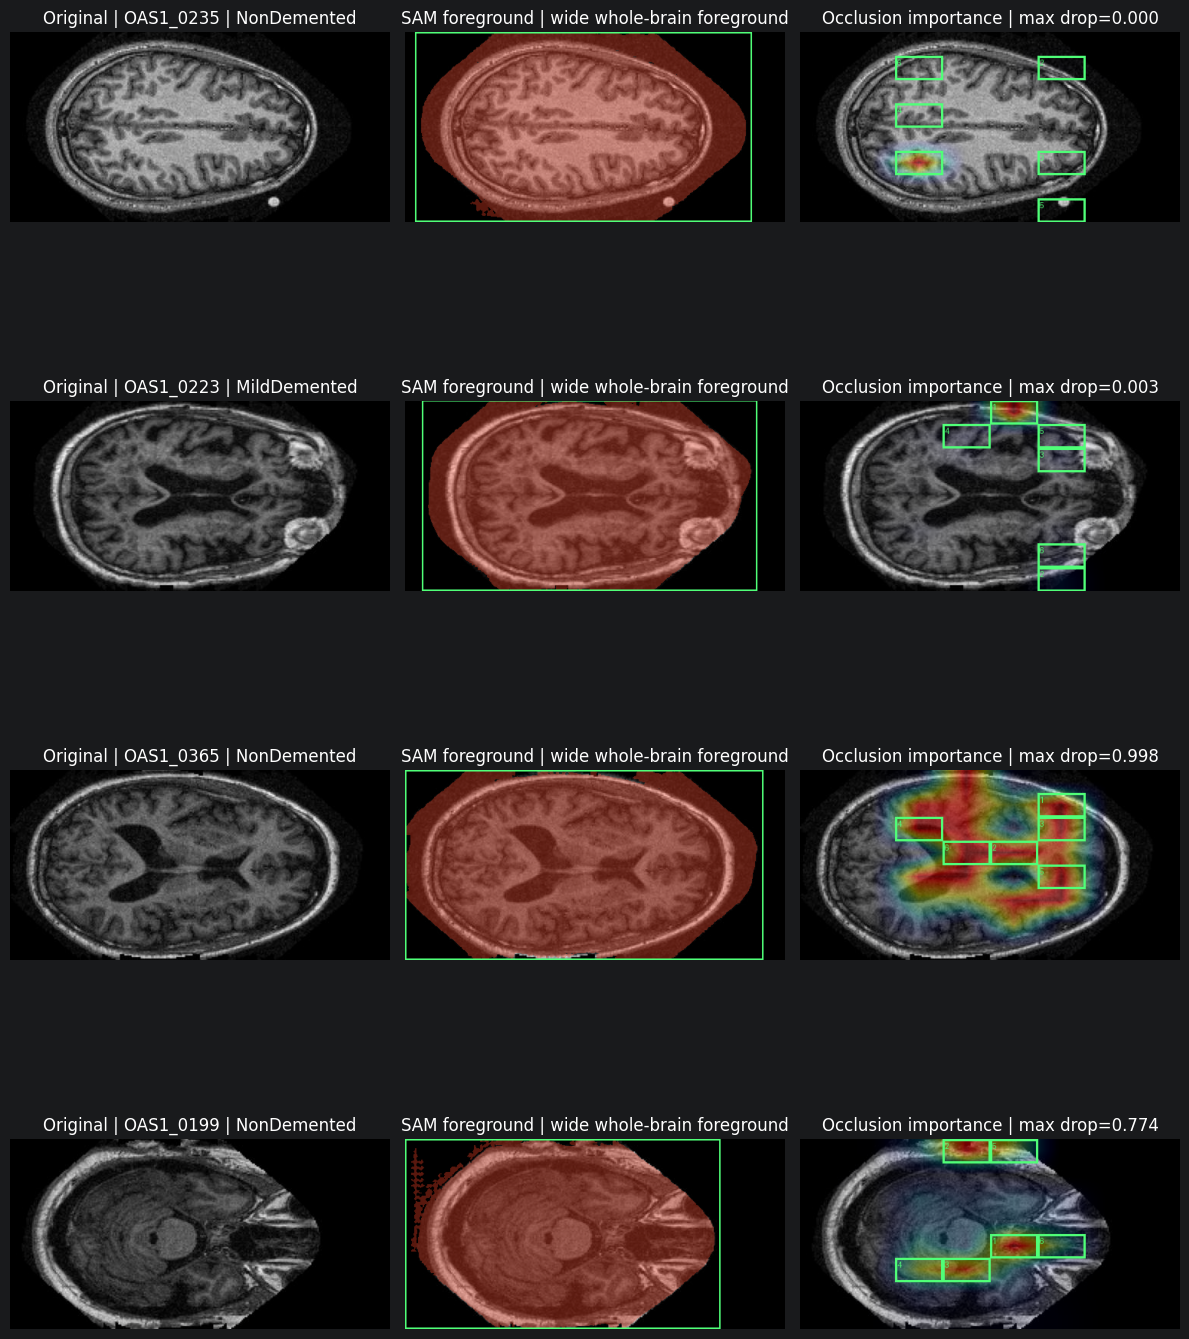

Preview saved: C:\Users\user\alzheimer\sam_occlusion_llm_pipeline\demo_assets\sam_occlusion_classifier_preview.png


In [10]:
fig, axes = plt.subplots(
    len(demo_cases_full),
    3,
    figsize=(12, 4 * len(demo_cases_full)),
)
if len(demo_cases_full) == 1:
    axes = np.asarray([axes])

for row_index, (_, row) in enumerate(demo_cases_full.iterrows()):
    original = Image.open(row["representative_image_path"]).convert("RGB")
    sam_overlay = Image.open(row["overlay_path"]).convert("RGB")
    heatmap = Image.open(row["top_patch_path"]).convert("RGB")

    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title(
        f"Original | {row['patient_id']} | {row['class_name']}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(sam_overlay)
    axes[row_index, 1].set_title(
        f"SAM foreground | {row['segmentation_scope_note']}"
    )
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(heatmap)
    axes[row_index, 2].set_title(
        f"Occlusion importance | max drop={row['max_confidence_drop']:.3f}"
    )
    axes[row_index, 2].axis("off")

plt.tight_layout()
preview_path = ASSET_DIR / "sam_occlusion_classifier_preview.png"
plt.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Preview saved: {preview_path}")


## 8. 실제 LLM 연결 확인


In [11]:
def normalize_api_base(base_url):
    return base_url.rstrip("/")


def list_llm_models():
    url = normalize_api_base(LLM_API_BASE) + "/models"
    headers = {"Authorization": f"Bearer {LLM_API_KEY}"}
    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()
    data = response.json()
    model_ids = [item["id"] for item in data.get("data", []) if "id" in item]
    return model_ids, data


if RUN_LLM:
    try:
        available_models, raw_model_response = list_llm_models()
    except Exception as exc:
        raise RuntimeError(
            "LLM endpoint에 연결할 수 없습니다.\n"
            f"현재 LLM_API_BASE={LLM_API_BASE}\n\n"
            "해결 방법:\n"
            "1. LM Studio를 쓰면 Local Server를 켜고 LLM_API_BASE를 http://localhost:1234/v1 로 둡니다.\n"
            "2. Ollama를 쓰면 Ollama를 실행하고 LLM_API_BASE를 http://localhost:11434/v1 로 바꿉니다.\n"
            "3. OpenAI API를 쓰면 LLM_API_BASE=https://api.openai.com/v1, LLM_API_KEY를 설정합니다.\n"
        ) from exc

    if not LLM_MODEL:
        assert available_models, "models endpoint는 열렸지만 사용 가능한 model id가 없습니다."
        LLM_MODEL = available_models[0]

    print("LLM endpoint connected.")
    print(f"LLM_API_BASE: {LLM_API_BASE}")
    print(f"LLM_MODEL   : {LLM_MODEL}")
    print("Available models:", available_models[:10])
else:
    print("RUN_LLM=False: LLM report 생성을 건너뜁니다.")


LLM endpoint connected.
LLM_API_BASE: http://127.0.0.1:1234/v1
LLM_MODEL   : google/gemma-4-e4b
Available models: ['google/gemma-4-e4b', 'text-embedding-nomic-embed-text-v1.5']


## 9. LLM prompt와 report 생성


In [12]:
SYSTEM_PROMPT = """
너는 의료 진단을 확정하는 의사가 아니다.
너의 역할은 이미 계산된 MRI screening model 결과, SAM foreground segmentation 결과, occlusion sensitivity heatmap을 사람이 읽기 쉬운 한국어 보고서로 정리하는 것이다.
모델이 제공하지 않은 의학적 소견을 새로 만들어내지 마라.
SAM mask는 알츠하이머 병변 위치가 아니라 brain foreground 보조 시각화라고 설명하라.
Occlusion heatmap은 임상 병변 ROI가 아니라 model-derived importance region이라고 설명하라.
최종 문장에는 이 결과가 진단이 아니라 연구용 screening 결과임을 분명히 적어라.
""".strip()


def model_decision_text(pred_label):
    return "비정상 의심" if int(pred_label) == 1 else "정상 가능성"


def confidence_band(probability, threshold):
    distance = abs(float(probability) - float(threshold))
    if distance < 0.05:
        return "threshold에 매우 가까운 경계 결과"
    if distance < 0.15:
        return "중간 정도의 확신"
    return "상대적으로 명확한 결과"


def build_case_payload(row):
    return {
        "patient_id": str(row["patient_id"]),
        "case_type": str(row["case_type"]),
        "experimental_ground_truth_class": str(row["class_name"]),
        "sam_model": str(row["segmentation_backend"]),
        "sam_score": round(float(row["sam_score"]), 4),
        "segmentation_scope_note": str(row["segmentation_scope_note"]),
        "classifier": "BiomedCLIP frozen image encoder + adapter probe",
        "classifier_input": "original MRI feature cache, patient-level aggregation",
        "task": "Stage 1 binary screening: NonDemented vs Demented",
        "patient_level_probability_demented": round(float(row["probability"]), 4),
        "representative_slice_probability_demented": round(float(row["original_slice_probability"]), 4),
        "representative_slice_selection": str(row["representative_slice_selection"]),
        "threshold": round(float(row["threshold"]), 4),
        "prediction": model_decision_text(row["pred_label"]),
        "confidence_band": confidence_band(row["probability"], row["threshold"]),
        "occlusion_target_class": (
            "demented class" if int(row["predicted_class_for_heatmap"]) == 1 else "non-demented class"
        ),
        "max_confidence_drop_by_occlusion": round(float(row["max_confidence_drop"]), 4),
        "mean_positive_confidence_drop_by_occlusion": round(float(row["mean_positive_confidence_drop"]), 4),
        "sam_mask_interpretation": (
            "SAM 기반 brain foreground mask이며, 알츠하이머 병변 위치나 전문의 annotation이 아님"
        ),
        "occlusion_interpretation": (
            "patch를 가렸을 때 classifier 확신이 떨어진 정도를 나타내는 model-derived importance map이며, "
            "임상 병변 ROI가 아님"
        ),
        "sam_overlay_path": str(row["overlay_path"]),
        "occlusion_heatmap_path": str(row["heatmap_overlay_path"]),
        "occlusion_top_patch_path": str(row["top_patch_path"]),
    }


def build_llm_prompt(payload):
    return f"""
아래 JSON은 Alzheimer MRI multi-foundation screening pipeline의 한 환자 예시 결과다.
이 정보를 바탕으로 한국어 보고서를 작성하라.

보고서 형식:
1. 입력 및 파이프라인 요약
2. SAM foreground segmentation 결과
3. BiomedCLIP adapter classifier 판단
4. Occlusion sensitivity 해석
5. 통합 해석과 주의점

제약:
- 진단, 확진, 병변 검출이라고 표현하지 말 것
- SAM mask를 병변 위치로 해석하지 말 것
- occlusion heatmap을 임상 ROI로 해석하지 말 것
- ground truth class는 실험 검증용 metadata로만 다룰 것
- MRI에서 관찰되지 않은 의학적 소견을 생성하지 말 것

JSON:
{json.dumps(payload, ensure_ascii=False, indent=2)}
""".strip()


def call_llm(prompt):
    url = normalize_api_base(LLM_API_BASE) + "/chat/completions"
    headers = {
        "Authorization": f"Bearer {LLM_API_KEY}",
        "Content-Type": "application/json",
    }
    body = {
        "model": LLM_MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
    }
    response = requests.post(
        url,
        headers=headers,
        json=body,
        timeout=LLM_TIMEOUT_SECONDS,
    )
    response.raise_for_status()
    data = response.json()
    return data["choices"][0]["message"]["content"]


In [13]:
report_records = []

if RUN_LLM:
    for _, row in demo_cases_full.iterrows():
        payload = build_case_payload(row)
        prompt = build_llm_prompt(payload)
        report = call_llm(prompt)

        safe_id = re.sub(r"[^A-Za-z0-9_]+", "_", payload["patient_id"])
        prompt_path = PROMPT_DIR / f"{safe_id}_prompt.md"
        report_path = REPORT_DIR / f"{safe_id}_llm_report.md"
        prompt_path.write_text(prompt, encoding="utf-8")
        report_path.write_text(report, encoding="utf-8")

        report_records.append({
            **payload,
            "llm_api_base": LLM_API_BASE,
            "llm_model": LLM_MODEL,
            "prompt_path": str(prompt_path),
            "report_path": str(report_path),
        })

    report_df = pd.DataFrame(report_records)
    report_index_path = OUTPUT_DIR / "sam_occlusion_llm_report_index.csv"
    report_df.to_csv(report_index_path, index=False, encoding="utf-8-sig")
    display(
        report_df[
            [
                "patient_id",
                "case_type",
                "prediction",
                "patient_level_probability_demented",
                "max_confidence_drop_by_occlusion",
                "llm_model",
                "report_path",
            ]
        ]
    )
    print(f"Report index saved: {report_index_path}")
else:
    report_df = pd.DataFrame()
    print("RUN_LLM=False: report_df는 비어 있습니다.")


,patient_id,case_type,prediction,patient_level_probability_demented,max_confidence_drop_by_occlusion,llm_model,report_path
0,OAS1_0235,정상으로 맞힌 낮은 위험도 사례,정상 가능성,0.0000,0.0000,google/gemma-4-e4b,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
1,OAS1_0223,비정상으로 맞힌 높은 위험도 사례,비정상 의심,0.9003,0.0034,google/gemma-4-e4b,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
2,OAS1_0365,threshold 근처의 경계 사례,비정상 의심,0.3265,0.9978,google/gemma-4-e4b,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...
3,OAS1_0199,오분류 사례,비정상 의심,0.4215,0.7735,google/gemma-4-e4b,C:\Users\user\alzheimer\sam_occlusion_llm_pipe...


Report index saved: C:\Users\user\alzheimer\sam_occlusion_llm_pipeline\sam_occlusion_llm_report_index.csv


In [14]:
if RUN_LLM and not report_df.empty:
    for _, row in report_df.iterrows():
        display(Markdown(Path(row["report_path"]).read_text(encoding="utf-8")))


## Alzheimer MRI 다중 기반 스크리닝 모델 분석 보고서

**환자 ID:** OAS1\_0235
**분석 목적:** 초기 1단계 이진 분류(NonDemented vs Demented)를 위한 연구용 스크리닝 결과 정리.

---

### 1. 입력 및 파이프라인 요약 (Input & Pipeline Summary)

본 분석은 MRI 데이터를 기반으로 설계된 다중 모달리티 스크리닝 파이프라인을 통해 수행되었습니다. 해당 환자는 임상적으로 '정상으로 맞힌 낮은 위험도 사례'로 분류되었으며, 모델의 실험적 검증용 메타데이터(experimental ground truth class)는 **NonDemented**입니다.

*   **분석 목표:** NonDemented와 Demented 간의 이진 스크리닝 (Stage 1 binary screening).
*   **사용 데이터:** 원본 MRI 특징 캐시 및 환자 수준 집계(patient-level aggregation)를 활용했습니다.
*   **모델 구성:** SAM 기반 전처리 및 BiomedCLIP 어댑터 분류기 조합을 사용하였습니다.

### 2. SAM Foreground Segmentation 결과 (SAM Mask Visualization)

Segmentation 모델로 **SAM vit\_b**가 사용되었으며, 전체적인 스코어는 0.9889를 기록했습니다.

*   **시각화 범위:** 광범위한 전뇌 영역(wide whole-brain foreground)을 포괄하는 마스크가 생성되었습니다.
*   **해석 주의점:** 이 SAM 마스크는 알츠하이머 병변의 위치나 전문의의 임상적 주석(annotation)이 아닙니다. 이는 모델 기반의 **전체 뇌 구조물 전경(brain foreground)**을 시각화한 보조적인 역할을 수행합니다.

### 3. BiomedCLIP Adapter Classifier 판단 (Classification Result)

BiomedCLIP frozen image encoder와 어댑터 프로브를 활용하여 분류가 진행되었습니다.

*   **분류 예측:** 모델은 해당 환자에 대해 **'정상 가능성'**을 예측했습니다.
*   **확신도 및 임계값:** 설정된 임계값(threshold) 0.375 대비, Demented 클래스에 대한 환자 수준 확률과 대표 슬라이스 확률 모두 0.0으로 매우 낮게 측정되었습니다.
*   **결론 신뢰도:** 전반적인 결과는 **상대적으로 명확한 결과**로 판단됩니다.

### 4. Occlusion Sensitivity 해석 (Model-Derived Importance Map)

모델의 안정성을 평가하기 위해 가려짐(Occlusion) 민감도 분석이 수행되었습니다. 이 분석은 'non-demented class'를 기준으로 진행되었습니다.

*   **민감도 지표:** 패치를 가렸을 때 분류기의 확신도가 떨어진 정도를 나타내는 **모델 기반 중요 영역 맵(model-derived importance map)**이 생성되었습니다.
*   **결과 분석:** 최대 신뢰도 하락 폭(max\_confidence\_drop) 및 평균 양성 신뢰도 하락 폭(mean\_positive\_confidence\_drop) 모두 **0.0**을 기록했습니다.
*   **해석 주의점:** 이 맵은 임상적으로 의미 있는 병변 영역(ROI)이 아니며, 모델의 예측에 기여하는 중요도를 나타내는 지표입니다.

### 5. 통합 해석과 주의점 (Integrated Interpretation and Caveats)

종합적으로 볼 때, OAS1\_0235 환자는 스크리닝 파이프라인을 통해 **낮은 위험도(NonDemented)**의 경향성을 보였습니다. SAM 마스크는 전반적인 뇌 구조물 영역을 시각화하며, 분류기는 높은 확신도를 바탕으로 정상 가능성을 제시했습니다. 또한, 가려짐 민감도 분석 결과가 매우 안정적이라는 점은 모델 예측의 견고함을 뒷받침합니다.

**🚨 중요 고지 사항:**
본 보고서는 MRI 데이터를 활용하여 설계된 **연구용 스크리닝(screening)** 결과를 정리한 것입니다. 여기에 제시된 모든 수치와 해석은 인공지능 모델의 계산 결과에 기반하며, 이는 어떠한 경우에도 의학적 진단, 확진 또는 임상적 결론으로 간주되어서는 안 됩니다. 최종적인 의료 판단은 반드시 전문 의료진의 직접적인 검토를 거쳐야 합니다.

## 🧠 Alzheimer MRI 다중 기반 스크리닝 모델 분석 보고서

**환자 ID:** OAS1\_0223
**분석 목적:** 첨단 AI 모델을 활용한 초기 연구용 스크리닝 결과 정리 및 해석 보조 자료 제공.

---

### 1. 입력 및 파이프라인 요약 (Input and Pipeline Summary)

본 분석은 환자 ID `OAS1_0223`의 MRI 데이터를 기반으로 진행된 다중 기반(Multi-foundation) 스크리닝 파이프라인의 결과입니다. 이 모델은 초기 단계에서 정상군과 치매 의심군을 구분하는 2진 분류(Binary Screening)를 목표로 합니다.

*   **사례 유형:** 비정상적으로 높은 위험도를 보인 사례 (High-risk misclassification case).
*   **실험 검증용 메타데이터:** 해당 환자는 실험 설계 상 'MildDemented' 클래스로 지정된 metadata가 존재합니다. (이는 모델의 진단적 판단 근거가 아닌, 연구 목적으로 제공된 분류 정보입니다.)
*   **분석 파이프라인 구성:** SAM 기반 구조 분석 $\rightarrow$ BiomedCLIP 어댑터 분류기 적용 $\rightarrow$ Occlusion Sensitivity 분석 순으로 진행되었습니다.

### 2. SAM Foreground Segmentation 결과 (SAM Segmentation Result)

SAM(Segment Anything Model)은 MRI 이미지에서 전반적인 뇌 영역을 시각화하는 데 사용되었습니다.

*   **사용 모델:** SAM vit\_b
*   **분석 점수 (Score):** 0.9922로 매우 높은 일관성을 보였습니다.
*   **시각화 범위:** 이 마스크는 **광범위한 전뇌 영역(wide whole-brain foreground)**을 포괄하는 구조적 시각화 결과입니다.
*   **주의사항:** SAM이 생성한 마스크는 알츠하이머 병변의 위치를 나타내거나 전문의가 직접 주석을 단 임상적인 의미를 가지지 않는, **뇌 전경(brain foreground) 보조 시각화 자료**로 해석해야 합니다.

### 3. BiomedCLIP Adapter Classifier 판단 (BiomedCLIP Classification Judgment)

SAM으로 구조적 영역이 정의된 후, BiomedCLIP 어댑터 분류기가 원본 MRI 특징 캐시를 활용하여 환자 수준의 위험도를 평가했습니다.

*   **분석 방식:** 원본 MRI 특징과 환자 전체 데이터를 종합적으로 고려한 단계 1 이진 스크리닝을 수행했습니다.
*   **판단 결과 (Demented Class):**
    *   환자 레벨 확률: 0.9003
    *   대표 슬라이스(Representative Slice) 확률: 1.0
*   **예측:** 모델은 해당 환자를 **'비정상 의심'**으로 분류했습니다.
*   **신뢰도:** 예측 결과는 상대적으로 명확한 높은 신뢰도를 보였습니다.

### 4. Occlusion Sensitivity 해석 (Occlusion Sensitivity Interpretation)

이 분석은 이미지의 특정 영역(패치)을 가렸을 때, 모델의 확신도가 얼마나 떨어지는지를 측정하는 **모델 기반 중요도 지도(model-derived importance map)**를 생성합니다. 이는 임상적으로 정의된 병변 영역(ROI)과는 무관한 개념입니다.

*   **분석 목표:** 'demented class'에 대한 분류기의 민감도를 테스트했습니다.
*   **결과 해석:**
    *   최대 확신도 하락 폭 (Max Confidence Drop): 0.0034
    *   평균 확신도 하락 폭 (Mean Positive Confidence Drop): 0.0003
*   **의미:** 패치를 가렸을 때 분류기의 전반적인 확신도가 비교적 낮은 수준으로 떨어졌음을 보여줍니다.

### 5. 통합 해석과 주의점 (Integrated Interpretation and Caution)

#### 종합 요약
본 스크리닝 파이프라인은 SAM 기반 구조 분석 및 BiomedCLIP 분류기를 통해 해당 환자에게서 'Demented' 클래스에 대한 높은 확률(0.9003)을 포착했습니다. Occlusion Sensitivity 분석 결과는 모델의 전반적인 판단 근거가 특정 영역에 과도하게 의존하지 않음을 시사합니다.

#### ⚠️ 중요 주의사항 (Disclaimer)
**본 보고서는 인공지능 모델이 수행한 연구용 스크리닝(Screening) 결과일 뿐이며, 어떠한 경우에도 최종적인 의료 진단이나 확정적 판단으로 사용될 수 없습니다.**

1.  **진단 불가:** 이 분석은 의학적 진단을 대체할 수 없으며, 반드시 숙련된 신경과 전문의의 임상적 검토와 종합적인 판독이 필요합니다.
2.  **모델 해석 제한:** SAM 마스크는 뇌 전경 시각화 자료이며, Occlusion Heatmap은 모델 내부의 중요도 지표일 뿐입니다. 이 결과들을 병변 위치나 임상 ROI로 오해해서는 안 됩니다.
3.  **연구 목적 한정:** 본 보고서에 제시된 모든 수치와 해석은 **연구 및 개발 목적으로만 활용되어야 합니다.**

# [연구용] MRI 스크리닝 모델 분석 보고서

**환자 ID:** OAS1\_0365
**분석 목적:** Alzheimer MRI Multi-Foundation Screening Pipeline을 통한 연구용 초기 스크리닝 결과 정리
***
**⚠️ 중요 고지 사항 (Disclaimer)**
본 보고서는 인공지능(AI) 기반의 **연구용 스크리닝 모델**이 계산한 통계적 결과를 사람이 이해하기 쉽도록 재구성한 것입니다. 여기에 제시된 모든 수치와 해석은 의학적인 진단, 확진, 또는 임상적 결론을 대체할 수 없습니다. 최종 판단과 치료 계획은 반드시 전문 의료진의 종합적인 임상 검토를 거쳐야 합니다.
***

## 1. 입력 및 파이프라인 요약 (Input and Pipeline Summary)

| 항목 | 내용 | 설명 |
| :--- | :--- | :--- |
| **환자 ID** | OAS1\_0365 | 분석 대상 환자의 식별 번호입니다. |
| **케이스 유형** | Threshold 근처의 경계 사례 (Borderline Case) | 모델이 판단 기준(Threshold)에 매우 가까운 애매한 결과를 보인 경우로 분류됩니다. |
| **실험 검증용 메타데이터** | NonDemented | 이 값은 본 분석을 위해 사용된 실험적 비교군 정보일 뿐, 임상 진단으로 해석되어서는 안 됩니다. |
| **스크리닝 목표 (Task)** | Stage 1 binary screening: NonDemented vs Demented | 비치매성(NonDemented)과 치매성(Demented) 두 상태 중 어느 쪽에 가까운지 이진 분류를 수행하는 것이 목표입니다. |

## 2. SAM Foreground Segmentation 결과 (SAM Mask Visualization)

**사용 모델:** SAM vit\_b
**분석 범위:** Wide whole-brain foreground
**모델 점수 (SAM Score):** 0.9886

*   **결과 해석:** 본 분석에 사용된 SAM(Segment Anything Model)은 **뇌 전경부(Brain Foreground)**를 보조적으로 시각화하는 마스크를 생성했습니다. 이 마스크는 알츠하이머 병변의 위치나 전문의가 직접 표시한 해부학적 영역을 나타내는 것이 아니며, 단순히 뇌 구조물의 경계를 파악하기 위한 **보조적인 시각화 자료**로 활용되었습니다.
*   **활용 경로:** `OAS1_0365_sam_foreground_overlay.png`

## 3. BiomedCLIP Adapter Classifier 판단 (Classification Judgment)

| 항목 | 값 | 해석 |
| :--- | :--- | :--- |
| **분류기 모델** | BiomedCLIP frozen image encoder + adapter probe | MRI 특징 캐시와 환자 수준의 정보를 종합하여 분류를 수행했습니다. |
| **환자 수준 확률 (Demented)** | 0.3265 | 전체적인 데이터를 기반으로 치매성 상태일 확률은 약 32.65%로 계산되었습니다. |
| **대표 슬라이스 확률 (Demented)** | 0.9992 | 모델이 가장 높은 증거를 발견했다고 판단한 특정 단면(Representative Slice)에서는 치매성 상태일 확률이 매우 높게 나타났습니다. |
| **판단 기준 (Threshold)** | 0.325 | 분류가 이루어진 임계값입니다. |
| **최종 예측** | 비정상 의심 (Suspicious) | 환자 수준의 확률(0.3265)이 설정된 임계값(0.325)에 매우 근접하여, 모델은 경계선상의 결과를 보인 것으로 판단했습니다. |

## 4. Occlusion Sensitivity 해석 (Model-Derived Importance Map Analysis)

**분석 목표:** 분류기(Classifier)가 특정 영역의 정보를 얼마나 중요하게 사용하는지 파악합니다.
**결과 유형:** Model-derived importance map (모델 기반 중요도 지도)

*   **개념 설명:** 이 히트맵은 MRI 이미지의 일부 패치(Patch)를 가렸을 때, 분류기의 확신도가 얼마나 떨어지는지를 보여주는 **모델이 계산한 중요 영역 맵**입니다. 이는 임상적으로 의미 있는 병변 위치(ROI)가 아닙니다.
*   **분석 결과:**
    *   **최대 신뢰도 하락 (Max Confidence Drop):** 0.9978
    *   **평균 양성 신뢰도 하락 (Mean Positive Confidence Drop):** 0.4137
*   **해석:** 모델은 이미지의 특정 영역(Top Patch)을 가렸을 때, 분류기의 확신도가 매우 크게 떨어지는 경향을 보였습니다. 이는 해당 영역이 모델의 판단에 중요한 영향을 미치는 **모델 기반 중요 영역**임을 시사합니다.
*   **활용 경로:** `OAS1_0365_occlusion_heatmap_overlay.png`

## 5. 통합 해석과 주의점 (Integrated Interpretation and Caveats)

### 종합 요약
본 스크리닝 파이프라인은 환자 OAS1\_0365의 MRI 데이터를 분석한 결과, 전반적인 확률(0.3265)은 설정된 임계값에 근접하는 **경계성**을 보였습니다. 그러나 모델이 가장 높은 증거를 발견했다고 판단한 특정 단면에서는 치매성 상태일 가능성이 매우 높게 나타났습니다 (0.9992). 또한, Occlusion Sensitivity 분석 결과는 이미지의 특정 영역이 분류기의 최종 결정에 중요한 역할을 하는 **모델 기반 중요 영역**임을 보여줍니다.

### 🚨 재차 강조하는 주의점
1.  **진단 불가:** 본 보고서의 모든 내용은 AI 모델의 통계적 계산 결과일 뿐이며, 어떠한 의학적 진단이나 확정적인 결론으로도 해석될 수 없습니다.
2.  **시각화 자료의 한계:** SAM 마스크는 뇌 전경부 보조 시각화이며, Occlusion Heatmap은 모델이 중요하다고 판단한 가상의 영역일 뿐입니다. 이들은 임상적 병변이나 해부학적 경계를 직접적으로 나타내지 않습니다.
3.  **연구 목적:** 본 결과는 오직 연구 및 개발 목적으로만 사용되어야 하며, 실제 환자 치료 결정에 활용되어서는 안 됩니다.

## Alzheimer MRI 다중 기반 스크리닝 모델 분석 보고서

**환자 ID:** OAS1\_0199
**분석 목적:** 초기 2진 분류(NonDemented vs Demented)를 위한 연구용 스크리닝 결과 정리
***

### 1. 입력 및 파이프라인 요약

본 보고서는 환자 OAS1\_0199의 MRI 데이터를 기반으로 구축된 다중 모달리티 스크리닝 모델의 결과를 종합적으로 분석한 것입니다. 해당 케이스는 실험 검증용 메타데이터 상 '오분류 사례(Misclassification case)'로 분류되었습니다.

**스크리닝 목표:** NonDemented와 Demented 두 클래스 간의 이진 분류를 수행하는 것이 주된 목적입니다.
**사용 모델 구성:** SAM (Segmentation Anything Model)과 BiomedCLIP 어댑터 분류기(Adapter Classifier)가 결합되어 환자 수준 및 대표 슬라이스 수준에서 확률적 평가를 진행했습니다.

### 2. SAM foreground segmentation 결과

SAM vit\_b 모델을 사용하여 MRI 영상의 전반적인 구조 정보를 추출하였습니다.
*   **분석 범위:** 광범위한 전체 뇌 영역(wide whole-brain foreground)에 대한 분할 마스크가 생성되었습니다.
*   **결과 해석:** 이 SAM 마스크는 **SAM 기반 brain foreground mask**이며, 알츠하이머 병변의 위치나 전문의의 임상적 주석(annotation)을 의미하지 않습니다. 이는 모델이 인식한 뇌 구조물의 전반적인 경계 시각화 자료로 활용됩니다.

### 3. BiomedCLIP adapter classifier 판단

BiomedCLIP 어댑터 분류기는 원본 MRI 특징 캐시와 환자 수준의 집계된 정보를 바탕으로 'NonDemented' 대 'Demented'에 대한 확률적 평가를 수행했습니다.

*   **환자 수준 예측:** Demented 클래스일 확률은 0.4215로 산출되었습니다.
*   **대표 슬라이스 예측:** 가장 높은 양성 증거(positive-evidence)가 포착된 대표 슬라이스에서는 Demented 클래스일 확률이 0.945로 매우 높게 나타났습니다.
*   **최종 판단:** 모델은 최종적으로 **'비정상 의심'**이라는 경계에 가까운 결과를 제시했습니다. 특히, 환자 수준의 예측 확률(0.4215)은 설정된 임계값(Threshold: 0.4)에 매우 근접한 경계 결과로 해석됩니다.

### 4. Occlusion sensitivity 해석 (가림 민감도 분석)

Occlusion Sensitivity Heatmap은 모델이 특정 영역의 정보를 얼마나 중요하게 판단하는지 측정하는 **모델 기반 중요도 지도(model-derived importance map)**입니다. 이는 임상 병변 ROI를 나타내는 것이 아닙니다.

*   **분석 대상:** Demented 클래스에 대한 확신도를 기준으로 분석되었습니다.
*   **결과 해석:**
    *   가장 높은 패치 가림으로 인한 신뢰도 하락 폭(Max Confidence Drop): 0.7735
    *   평균적인 패치 가림으로 인한 신뢰도 하락 폭(Mean Positive Confidence Drop): 0.1734
*   **의미:** 이 수치는 MRI 영상의 특정 영역(패치)를 인위적으로 가렸을 때, 분류기(Classifier)가 원래 가지고 있던 확신도가 얼마나 크게 떨어지는지를 보여줍니다. 이는 모델이 해당 패치를 중요하게 인식하고 있음을 나타내는 지표입니다.

### 5. 통합 해석과 주의점

종합적으로 볼 때, 본 환자 OAS1\_0199의 스크리닝 결과는 **'비정상 의심'**이라는 경계에 위치하며, 모델 예측값 간에 높은 변동성(환자 수준 vs 대표 슬라이스)을 보였습니다. SAM 마스크와 Occlusion Heatmap은 각각 뇌 구조물의 전반적인 시각화 및 모델의 중요도 판단 영역을 제공할 뿐이며, 이 자체로 임상적 의미를 부여해서는 안 됩니다.

**[필수 주의사항]**
본 보고서에 제시된 모든 결과는 **AI 기반 연구용 스크리닝(Screening) 결과**일 뿐입니다. 이는 의학적인 진단이나 확정적인 판단을 대체할 수 없으며, 최종적인 임상적 해석은 반드시 전문 의료진의 종합적인 검토가 필요합니다.

## 10. 최종 발표 문장


In [15]:
final_text = f"""
# Final Multi-Foundation Pipeline with Model-Derived Importance

본 프로젝트는 Alzheimer MRI 이미지를 대상으로 세 가지 foundation-model 기반 모듈과 설명 가능성 분석을 연결했다.

1. SAM foreground segmentation
- MRI slice에서 자동 box prompt를 생성하고, SAM ViT-B로 brain foreground mask를 만든다.
- 이 mask는 알츠하이머 병변 위치가 아니라 배경 제거와 전체 뇌 context 시각화를 위한 결과다.

2. BiomedCLIP adapter classifier
- frozen BiomedCLIP image encoder에서 추출한 feature에 adapter probe를 붙여 정상/비정상 screening을 수행한다.
- 환자 단위 5-fold 검증으로 data leakage를 줄였다.
- 복원된 OOF 성능은 sensitivity={oof_metrics['sensitivity']:.3f}, specificity={oof_metrics['specificity']:.3f},
  F1={oof_metrics['f1']:.3f}, AUROC={oof_metrics['auroc']:.3f}, AUPRC={oof_metrics['auprc']:.3f}이다.

3. Occlusion sensitivity
- 전문의 ROI annotation 없이, representative slice의 patch를 가려가며 classifier 확신 변화를 계산했다.
- 확신이 크게 감소한 patch를 model-derived importance region으로 시각화했다.
- 이 영역은 임상 병변 ROI가 아니라 모델 판단 민감도 지도다.

4. LLM report module
- SAM mask, classifier 확률, threshold, occlusion heatmap 요약을 structured prompt로 전달한다.
- LLM은 진단을 새로 생성하지 않고, 연구용 screening 결과를 사람이 읽기 쉬운 한국어 보고서로 변환한다.

따라서 최종 구조는 MRI -> SAM foreground segmentation -> BiomedCLIP adapter classification
-> occlusion-based importance visualization -> LLM report로 이어지는 multi-foundation Alzheimer MRI screening assistant이다.
""".strip()

final_text_path = OUTPUT_DIR / "final_presentation_text.md"
final_text_path.write_text(final_text, encoding="utf-8")
display(Markdown(final_text))
print(f"Saved: {final_text_path}")


# Final Multi-Foundation Pipeline with Model-Derived Importance

본 프로젝트는 Alzheimer MRI 이미지를 대상으로 세 가지 foundation-model 기반 모듈과 설명 가능성 분석을 연결했다.

1. SAM foreground segmentation
- MRI slice에서 자동 box prompt를 생성하고, SAM ViT-B로 brain foreground mask를 만든다.
- 이 mask는 알츠하이머 병변 위치가 아니라 배경 제거와 전체 뇌 context 시각화를 위한 결과다.

2. BiomedCLIP adapter classifier
- frozen BiomedCLIP image encoder에서 추출한 feature에 adapter probe를 붙여 정상/비정상 screening을 수행한다.
- 환자 단위 5-fold 검증으로 data leakage를 줄였다.
- 복원된 OOF 성능은 sensitivity=0.889, specificity=0.823,
  F1=0.720, AUROC=0.899, AUPRC=0.665이다.

3. Occlusion sensitivity
- 전문의 ROI annotation 없이, representative slice의 patch를 가려가며 classifier 확신 변화를 계산했다.
- 확신이 크게 감소한 patch를 model-derived importance region으로 시각화했다.
- 이 영역은 임상 병변 ROI가 아니라 모델 판단 민감도 지도다.

4. LLM report module
- SAM mask, classifier 확률, threshold, occlusion heatmap 요약을 structured prompt로 전달한다.
- LLM은 진단을 새로 생성하지 않고, 연구용 screening 결과를 사람이 읽기 쉬운 한국어 보고서로 변환한다.

따라서 최종 구조는 MRI -> SAM foreground segmentation -> BiomedCLIP adapter classification
-> occlusion-based importance visualization -> LLM report로 이어지는 multi-foundation Alzheimer MRI screening assistant이다.

Saved: C:\Users\user\alzheimer\sam_occlusion_llm_pipeline\final_presentation_text.md
